# PP_DementiaProgress v2.14 workflow figure

PIL-only workflow figure with corrected Box 4 wording. No matplotlib or Graphviz dependency.

In [1]:
from pathlib import Path
from dataclasses import dataclass
from PIL import Image, ImageDraw, ImageFont
import os

# =============================================================================
# PP_DementiaProgress v2.14 workflow figure
# PIL-only version for deterministic text placement and no matplotlib/graphviz dependency.
# =============================================================================

# Output folder for the generated workflow figure.
# This path assumes the notebook is being run from the notebooks/ directory.
OUTPUT_DIR = Path("../op/0_pipeline_arch_flow_diagram")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Audited project values
# =============================================================================
# These values are treated as fixed project-level counts for the v2.14 workflow.
# The assertions below verify that the split counts and event counts remain internally consistent.

prepared_visit_rows = 188_700
eligible_visits = 23_665
unique_participants = 10_671
progression_events = 4_390
progression_prevalence = progression_events / eligible_visits * 100

training_visits, validation_visits, heldout_visits = 16_593, 2_348, 4_724
training_participants, validation_participants, heldout_participants = 7_469, 1_067, 2_135
training_events, validation_events, heldout_events = 3_100, 418, 872

temporal_train_visits, temporal_test_visits = 19_352, 4_313
temporal_train_events, temporal_test_events = 3_672, 718

med_present_visits, empty_or_noninformative_visits = 22_751, 914

# Consistency checks. These help prevent accidental editing errors in figure counts.
assert training_visits + validation_visits + heldout_visits == eligible_visits
assert training_participants + validation_participants + heldout_participants == unique_participants
assert training_events + validation_events + heldout_events == progression_events
assert temporal_train_visits + temporal_test_visits == eligible_visits
assert temporal_train_events + temporal_test_events == progression_events
assert med_present_visits + empty_or_noninformative_visits == eligible_visits
assert round(progression_prevalence, 1) == 18.6

# =============================================================================
# Figure text
# =============================================================================
# Centralized text dictionary.
# Keeping figure labels here makes it easier to edit wording without touching drawing functions.

TEXT = {
    "title": "Analytic workflow for next-visit dementia progression prediction",
    "rows": [
        (
            "1. Data source",
            f"NACC investigator dataset with repeated visits, clinical/neuropsychological measures,\n"
            f"DRUG1–DRUG40 medication fields, comorbidities, and selected neuropathology variables\n"
            f"Prepared source: {prepared_visit_rows:,} visit-level records",
            "database",
            "navy",
            "blue",
        ),
        (
            "2. Eligible index visits",
            f"Current MCI visit with an observed subsequent visit; last visits without next-visit diagnosis excluded\n"
            f"Analytic cohort: {eligible_visits:,} MCI visits; {unique_participants:,} participants",
            "filter",
            "green",
            "green",
        ),
        (
            "3. Outcome definition",
            f"Next-visit dementia progression derived from subsequent NACC clinical diagnosis\n"
            f"Progression events: {progression_events:,}; event prevalence: {progression_prevalence:.1f}%",
            "target",
            "gold",
            "gold",
        ),
        (
            "5. Participant-level train-validation-test design",
            f"Participant-level train/validation/test split; no participant overlap\n"
            f"Training: {training_visits:,}; validation: {validation_visits:,}; held-out test: {heldout_visits:,} visits",
            "group",
            "teal",
            "teal",
        ),
        (
            "6. Preprocessing and leakage control",
            "Imputation, encoding, scaling where applicable, and model transformations were fit within training data\n"
            "and applied unchanged to validation and held-out test data",
            "shield",
            "blue",
            "blue",
        ),
        (
            "7. Model development",
            "Class-balanced logistic regression and histogram-based gradient boosting, with validation-guided selection and final\n"
            "refitting before held-out test evaluation",
            "laptop",
            "orange",
            "orange",
        ),
        (
            "8. Validation design and final testing",
            "Participant-level held-out test and validation-set calibration assessment\n"
            "Temporal validation (train: 2005–2018; test: 2019–2023)",
            "magnify",
            "blue",
            "blue",
        ),
        (
            "9. Primary performance evaluation",
            "AUROC, average precision, Brier score, balanced accuracy, and threshold-based metrics\n"
            "Bootstrap confidence intervals and medication-state incremental value",
            "bars",
            "red",
            "red",
        ),
    ],
    "predictor_title": "4. Predictor representations",
    "predictors": [
        (
            "4a. Clinical-only",
            "Standard clinical predictors only",
            "list",
            "purple",
            "dark",
        ),
        (
            "4b. Medication information",
            "DRUG1–DRUG40 medication-name fields cleaned into visit-level profiles",
            "pill",
            "blue",
            "navy",
        ),
        (
            "4c. Clinical and LLM-enhanced medication state",
            "Standard clinical predictors plus\nLLM-enhanced medication-state\nabstraction",
            "llm",
            "orange",
            "orange",
        ),
    ],
    "secondary_title": "10. Secondary analyses and safeguards",
    "secondary": [
        ("10a. Calibration", "Risk calibration\nand decision curves", "calibration", "purple"),
        ("10b. Sensitivity", "Robustness and\nsubgroup checks", "sliders", "blue"),
        ("10c. Model audit", "Split integrity and\nmodel-output audit", "clipboard", "green"),
        ("10d. Neuropathology", "Postmortem anchors;\nnot model predictors", "microscope", "orange"),
    ],
    "footer": (
        "Neuropathology variables were excluded from all predictive feature sets.\n"
        "Medication-derived features were interpreted as participant-state and clinical-complexity markers, "
        "not causal medication effects."
    ),
}

In [2]:
# =============================================================================
# Layout configuration
# =============================================================================
# This dataclass controls all spacing, sizing, and positioning.
# If you want to move visual elements, edit this section first.

@dataclass
class Layout:
    # -------------------------------------------------------------------------
    # Overall canvas size
    # -------------------------------------------------------------------------
    W: int = 2000
    H: int = 2180
    scale: float = 1.0

    # -------------------------------------------------------------------------
    # Outer margins and main box dimensions
    # -------------------------------------------------------------------------
    margin_x: int = 70
    title_y: int = 28
    box_x: int = 70
    box_w: int = 1860

    # -------------------------------------------------------------------------
    # Main box heights
    # -------------------------------------------------------------------------
    big_h: int = 145
    row_h: int = 128
    radius: int = 10

    # -------------------------------------------------------------------------
    # Equal vertical spacing control
    # -------------------------------------------------------------------------
    # These controls make all arrows the same length.
    # The y positions are recalculated by apply_equal_vertical_spacing().
    box_gap: int = 45
    arrow_inset: int = 8

    # -------------------------------------------------------------------------
    # Main left-column controls
    # -------------------------------------------------------------------------
    # These three values control the icon column, the vertical divider bar,
    # and the start position of the main text in every standard workflow row.
    #
    # Keep this relationship:
    #   icon_x < divider_x < text_x
    #
    # To move the vertical divider bar left:
    #   1. Decrease icon_x.
    #   2. Decrease divider_x.
    #   3. Decrease text_x.
    # -------------------------------------------------------------------------
    icon_x: int = 120       # controls icon position in main boxes
    divider_x: int = 185    # controls vertical divider bar position
    text_x: int = 240       # controls title/body text start position
    icon_s: int = 50        # icon size in main boxes

    # -------------------------------------------------------------------------
    # Font sizes
    # -------------------------------------------------------------------------
    title_font_size: int = 36
    heading_font_size: int = 32
    body_font_size: int = 27
    small_font_size: int = 26
    pred_title_font_size: int = 24
    footer_font_size: int = 25

    # -------------------------------------------------------------------------
    # Vertical positions
    # -------------------------------------------------------------------------
    # y_data is the starting y-position.
    # The other y positions are recalculated by apply_equal_vertical_spacing()
    # so all arrows have the same length.
    # -------------------------------------------------------------------------
    y_data: int = 78
    y_eligible: int = 265
    y_outcome: int = 452
    y_pred: int = 650
    y_split: int = 980
    y_preprocess: int = 1135
    y_model: int = 1290
    y_validate: int = 1445
    y_perf: int = 1600
    y_secondary: int = 1765
    y_footer: int = 1995

    # -------------------------------------------------------------------------
    # Predictor section controls: Box 4
    # -------------------------------------------------------------------------
    # These values control Box 4 and its three internal predictor cards.
    # -------------------------------------------------------------------------
    pred_h: int = 285
    pred_card_yoff: int = 70
    pred_card_h: int = 190

    # Small vertical gap between each predictor-card title and body text.
    # Lower value = body text moves closer to the title.
    pred_title_body_gap: int = 6

    # Equal-size inner cards for Box 4.
    # x positions are computed automatically in draw_predictors().
    pred_card_w: int = 555
    pred_card_gap: int = 45

    # Inner text controls for predictor cards.
    pred_card_title_xpad: int = 18
    pred_card_text_xpad: int = 24

    # Icon-first layout inside predictor cards.
    # Order: icon → small gap → text.
    pred_card_icon_xpad: int = 28
    pred_icon_text_gap: int = 14
    pred_card_icon_s: int = 28

    # -------------------------------------------------------------------------
    # Secondary analyses section controls: Box 10
    # -------------------------------------------------------------------------
    sec_h: int = 205
    sec_card_yoff: int = 65
    sec_card_h: int = 115

    # Equal-size inner cards for Box 10.
    # x positions are computed automatically in draw_secondary().
    sec_card_w: int = 405
    sec_card_gap: int = 35

    # Icon-first layout inside secondary-analysis cards.
    # Order: icon → small gap → text.
    sec_icon_xpad: int = 28
    sec_icon_text_gap: int = 8
    sec_icon_s: int = 24

    # Text padding inside secondary cards.
    sec_text_xpad: int = 24

    # -------------------------------------------------------------------------
    # Footer controls
    # -------------------------------------------------------------------------
    footer_h: int = 90

    # Footer icon placement.
    footer_icon_x: int = 120
    footer_icon_size: int = 38

    # Footer text placement.
    # Text is moved left while draw_footer() prevents overlap with the icon.
    footer_text_x: int = 155
    footer_icon_text_gap: int = 14
    footer_text_right_pad: int = 28
    footer_text_y_offset: int = 22

    # -------------------------------------------------------------------------
    # Output file name
    # -------------------------------------------------------------------------
    output_stem: str = "fig_pipeline_arch_flow_v0"

In [3]:
# =============================================================================
# Color palette
# =============================================================================
# COL controls border/icon/text colors.
# FILL controls box background colors.

COL = {
    "navy": "#0B2A66",
    "green": "#28652E",
    "gold": "#B18400",
    "purple": "#4A2C83",
    "blue": "#1E63AE",
    "teal": "#0E6F78",
    "orange": "#B44A14",
    "red": "#B11E23",
    "gray": "#8A8F98",
    "dark": "#111111",
    "info": "#36454F",
}

FILL = {
    "blue": "#F6FAFF",
    "green": "#F8FFF7",
    "gold": "#FFFDF4",
    "purple": "#FBF8FF",
    "teal": "#F6FFFF",
    "orange": "#FFF8F2",
    "red": "#FFF7F7",
    "gray": "#FAFAFA",
    "white": "#FFFFFF",
}


# =============================================================================
# Font utilities
# =============================================================================

def find_font(name="DejaVuSerif.ttf"):
    """
    Locate a usable serif font on the system.

    The function first tries to match the requested filename exactly.
    If that fails, it falls back to the first available candidate.
    """
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSerif-Bold.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSerif-Regular.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSerif-Bold.ttf",
    ]

    for p in candidates:
        if Path(p).exists() and Path(p).name == name:
            return p

    for p in candidates:
        if Path(p).exists():
            return p

    return None


def load_fonts(L):
    """
    Load all fonts used in the figure according to the Layout font sizes.
    """
    regular_path = find_font("DejaVuSerif.ttf")
    bold_path = find_font("DejaVuSerif-Bold.ttf")

    return {
        "title": ImageFont.truetype(bold_path or regular_path, L.title_font_size),
        "heading": ImageFont.truetype(bold_path or regular_path, L.heading_font_size),
        "body": ImageFont.truetype(regular_path, L.body_font_size),
        "small": ImageFont.truetype(regular_path, L.small_font_size),
        "small_bold": ImageFont.truetype(bold_path or regular_path, L.small_font_size),
        "pred_title": ImageFont.truetype(bold_path or regular_path, L.pred_title_font_size),
        "footer": ImageFont.truetype(regular_path, L.footer_font_size),
        "footer_bold": ImageFont.truetype(bold_path or regular_path, L.footer_font_size),
    }


# =============================================================================
# Basic drawing helpers
# =============================================================================

def text(draw, xy, s, font, fill="#111111", anchor=None, spacing=3, align="left"):
    """
    Draw multiline text at a specified location.
    """
    draw.multiline_text(
        xy,
        s,
        font=font,
        fill=fill,
        spacing=spacing,
        align=align,
        anchor=anchor,
    )


def center_text(draw, center_x, y, s, font, fill="#111111"):
    """
    Draw horizontally centered text.
    """
    bbox = draw.textbbox((0, 0), s, font=font)
    w = bbox[2] - bbox[0]
    draw.text((center_x - w / 2, y), s, font=font, fill=fill)


def round_box(draw, xy, outline, fill, radius=10, width=2):
    """
    Draw a rounded rectangle with a border.
    """
    draw.rounded_rectangle(
        xy,
        radius=radius,
        fill=fill,
        outline=outline,
        width=width,
    )


def centered_card_xs(outer_x, outer_w, card_w, n_cards, gap):
    """
    Compute x positions for equal-width inner cards centered inside an outer box.

    Parameters
    ----------
    outer_x : int
        Left x-position of the outer box.
    outer_w : int
        Width of the outer box.
    card_w : int
        Width of each inner card.
    n_cards : int
        Number of inner cards.
    gap : int
        Horizontal gap between cards.

    Returns
    -------
    list[int]
        Centered x positions for each inner card.
    """
    total_cards_w = n_cards * card_w + (n_cards - 1) * gap
    start_x = outer_x + (outer_w - total_cards_w) / 2
    return [int(round(start_x + i * (card_w + gap))) for i in range(n_cards)]


def wrap_text_to_width(draw, s, font, max_width):
    """
    Wrap text so it fits within a maximum pixel width.

    This prevents text from extending beyond the right edge of an inner box.
    Existing manual line breaks are preserved.
    """
    wrapped_lines = []

    for paragraph in str(s).split("\n"):
        words = paragraph.split()

        if not words:
            wrapped_lines.append("")
            continue

        current_line = words[0]

        for word in words[1:]:
            test_line = current_line + " " + word
            bbox = draw.textbbox((0, 0), test_line, font=font)
            test_w = bbox[2] - bbox[0]

            if test_w <= max_width:
                current_line = test_line
            else:
                wrapped_lines.append(current_line)
                current_line = word

        wrapped_lines.append(current_line)

    return "\n".join(wrapped_lines)


def wrapped_text(draw, xy, s, font, fill="#111111", max_width=300, spacing=2):
    """
    Draw wrapped multiline text inside a fixed-width area.

    Use this for inner boxes so text stays inside the card boundaries.
    """
    s_wrapped = wrap_text_to_width(draw, s, font, max_width)
    draw.multiline_text(xy, s_wrapped, font=font, fill=fill, spacing=spacing)


# =============================================================================
# Simple vector icons
# =============================================================================
# These icons are drawn directly with PIL shapes so the figure does not depend
# on external image files or icon libraries.

def draw_icon(draw, kind, x, y, s, color):
    """
    Draw a simple vector icon.

    Parameters
    ----------
    draw : PIL.ImageDraw.ImageDraw
        Drawing context.
    kind : str
        Icon type.
    x, y : float
        Icon center position.
    s : float
        Icon scale.
    color : str
        Icon color.
    """
    cx, cy = x, y

    if kind == "database":
        draw.rectangle([cx - s * .30, cy - s * .22, cx + s * .30, cy + s * .24], fill=color)
        for dy in [-.25, -.07, .12, .28]:
            draw.ellipse([cx - s * .30, cy + s * dy - s * .08, cx + s * .30, cy + s * dy + s * .08], fill=color)
            draw.ellipse([cx - s * .30, cy + s * dy - s * .03, cx + s * .30, cy + s * dy + s * .03], fill="white")

    elif kind == "calendar":
        draw.rounded_rectangle([cx - s * .38, cy - s * .30, cx + s * .38, cy + s * .34], radius=5, outline=color, width=6)
        draw.line([cx - s * .38, cy - s * .06, cx + s * .38, cy - s * .06], fill=color, width=5)
        for dx in [-.22, 0, .22]:
            for dy in [.08, .25]:
                draw.rectangle([cx + s * dx - 5, cy + s * dy - 5, cx + s * dx + 5, cy + s * dy + 5], fill=color)

    elif kind == "target":
        for r, w in [(0.33, 5), (0.22, 4), (0.10, 4)]:
            draw.ellipse([cx - s * r, cy - s * r, cx + s * r, cy + s * r], outline=color, width=w)
        draw.line([cx, cy, cx + s * .40, cy - s * .40], fill=color, width=5)
        draw.polygon([(cx + s * .35, cy - s * .58), (cx + s * .58, cy - s * .58), (cx + s * .46, cy - s * .34)], fill=color)

    elif kind == "list":
        draw.rounded_rectangle([cx - s * .36, cy - s * .22, cx - s * .16, cy + s * .22], radius=5, fill=color)
        for dy in [-.16, 0, .16]:
            draw.ellipse([cx - s * .04, cy + s * dy - 4, cx + s * .04, cy + s * dy + 4], fill=color)
            draw.line([cx + s * .10, cy + s * dy, cx + s * .38, cy + s * dy], fill=color, width=4)

    elif kind == "pill":
        draw.rounded_rectangle([cx - s * .16, cy - s * .30, cx + s * .16, cy + s * .30], radius=8, fill=color)
        draw.line([cx - s * .11, cy - s * .12, cx + s * .11, cy - s * .12], fill="white", width=3)
        draw.ellipse([cx + s * .18, cy + s * .16, cx + s * .36, cy + s * .34], outline=color, width=4)

    elif kind == "doc":
        draw.rounded_rectangle([cx - s * .22, cy - s * .32, cx + s * .24, cy + s * .32], radius=4, fill=color)
        draw.polygon([(cx + s * .06, cy - s * .32), (cx + s * .24, cy - s * .14), (cx + s * .06, cy - s * .14)], fill="white")
        for dy in [-.02, .14, .28]:
            draw.line([cx - s * .12, cy - s * .18 + s * dy, cx + s * .08, cy - s * .18 + s * dy], fill="white", width=3)

    elif kind == "group":
        draw.ellipse([cx - s * .12, cy - s * .20, cx + s * .12, cy + s * .04], fill=color)
        draw.ellipse([cx - s * .40, cy - s * .14, cx - s * .20, cy + s * .06], fill=color)
        draw.ellipse([cx + s * .20, cy - s * .14, cx + s * .40, cy + s * .06], fill=color)
        draw.rounded_rectangle([cx - s * .20, cy + s * .02, cx + s * .20, cy + s * .34], radius=6, fill=color)
        draw.rounded_rectangle([cx - s * .48, cy + s * .10, cx - s * .25, cy + s * .34], radius=5, fill=color)
        draw.rounded_rectangle([cx + s * .25, cy + s * .10, cx + s * .48, cy + s * .34], radius=5, fill=color)

    elif kind == "gears":
        draw.ellipse([cx - s * .28, cy - s * .16, cx - s * .02, cy + s * .10], outline=color, width=6)
        draw.ellipse([cx + s * .05, cy + s * .00, cx + s * .27, cy + s * .22], outline=color, width=6)

    elif kind == "laptop":
        draw.rectangle([cx - s * .30, cy - s * .15, cx + s * .30, cy + s * .18], outline=color, width=5)
        draw.polygon([(cx - s * .40, cy + s * .28), (cx + s * .40, cy + s * .28), (cx + s * .30, cy + s * .18), (cx - s * .30, cy + s * .18)], fill=color)
        draw.line([cx - s * .17, cy, cx - s * .03, cy - s * .12, cx + s * .08, cy - s * .03, cx + s * .23, cy - s * .18], fill=color, width=4)

    elif kind == "magnify":
        draw.ellipse([cx - s * .25, cy - s * .25, cx + s * .15, cy + s * .15], outline=color, width=6)
        draw.line([cx + s * .10, cy + s * .10, cx + s * .34, cy + s * .34], fill=color, width=6)

    elif kind == "bars":
        for i, h in enumerate([.18, .32, .48]):
            x0 = cx - s * .30 + i * s * .22
            draw.rectangle([x0, cy + s * .25 - h * s, x0 + s * .10, cy + s * .25], fill=color)
        draw.line([cx - s * .38, cy + s * .27, cx + s * .38, cy + s * .27], fill=color, width=5)

    elif kind == "filter":
        # Eligibility icon: funnel indicating cohort filtering/selection.
        draw.polygon([
            (cx - s * .38, cy - s * .32),
            (cx + s * .38, cy - s * .32),
            (cx + s * .12, cy - s * .02),
            (cx + s * .06, cy + s * .34),
            (cx - s * .08, cy + s * .26),
            (cx - s * .12, cy - s * .02),
        ], fill=color)

    elif kind == "llm":
        # LLM icon: small processor/chip representing language-model abstraction.
        draw.rounded_rectangle([cx - s * .30, cy - s * .26, cx + s * .30, cy + s * .26], radius=6, outline=color, width=4)
        for dx in [-.18, 0, .18]:
            draw.line([cx + s * dx, cy - s * .26, cx + s * dx, cy - s * .42], fill=color, width=3)
            draw.line([cx + s * dx, cy + s * .26, cx + s * dx, cy + s * .42], fill=color, width=3)
        draw.line([cx - s * .18, cy - s * .06, cx + s * .18, cy - s * .06], fill=color, width=3)
        draw.line([cx - s * .18, cy + s * .10, cx + s * .18, cy + s * .10], fill=color, width=3)

    elif kind == "model":
        # Model-development icon: connected nodes representing learned model structure.
        nodes = [
            (cx - s * .28, cy - s * .18),
            (cx - s * .28, cy + s * .20),
            (cx + s * .03, cy),
            (cx + s * .32, cy - s * .22),
            (cx + s * .32, cy + s * .24),
        ]
        for a, b in [(0, 2), (1, 2), (2, 3), (2, 4)]:
            draw.line([nodes[a][0], nodes[a][1], nodes[b][0], nodes[b][1]], fill=color, width=3)
        for px, py in nodes:
            draw.ellipse([px - s * .08, py - s * .08, px + s * .08, py + s * .08], fill=color)

    elif kind == "clipboard":
        # Audit/reporting icon: clipboard with check lines.
        draw.rounded_rectangle([cx - s * .28, cy - s * .32, cx + s * .28, cy + s * .34], radius=5, outline=color, width=4)
        draw.rounded_rectangle([cx - s * .13, cy - s * .43, cx + s * .13, cy - s * .25], radius=4, fill=color)
        for dy in [-.10, .08, .25]:
            draw.rectangle([cx - s * .17, cy + s * dy - 3, cx - s * .10, cy + s * dy + 4], fill=color)
            draw.line([cx - s * .02, cy + s * dy, cx + s * .18, cy + s * dy], fill=color, width=3)

    elif kind == "calibration":
        # Calibration/DCA icon: axes with a calibration-like curve and points.
        draw.line([cx - s * .38, cy + s * .30, cx + s * .40, cy + s * .30], fill=color, width=4)
        draw.line([cx - s * .35, cy + s * .30, cx - s * .35, cy - s * .35], fill=color, width=4)
        pts = [
            (cx - s * .28, cy + s * .18),
            (cx - s * .10, cy + s * .04),
            (cx + s * .08, cy - s * .02),
            (cx + s * .28, cy - s * .22),
        ]
        draw.line(pts, fill=color, width=4)
        for px, py in pts:
            draw.ellipse([px - 3, py - 3, px + 3, py + 3], fill=color)

    elif kind == "sliders":
        # Sensitivity-check icon: horizontal sliders representing analytic variation.
        for j, dy in enumerate([-0.22, 0.00, 0.22]):
            y0 = cy + s * dy
            draw.line([cx - s * .36, y0, cx + s * .36, y0], fill=color, width=4)
            knob_x = cx + s * ([-0.16, 0.18, -0.02][j])
            draw.ellipse([knob_x - s * .08, y0 - s * .08, knob_x + s * .08, y0 + s * .08], fill=color)

    elif kind == "shield":
        # Stability/audit icon: shield with a check mark.
        draw.polygon([
            (cx, cy - s * .38),
            (cx + s * .34, cy - s * .22),
            (cx + s * .28, cy + s * .24),
            (cx, cy + s * .42),
            (cx - s * .28, cy + s * .24),
            (cx - s * .34, cy - s * .22),
        ], fill=color)
        draw.line([cx - s * .14, cy + s * .02, cx - s * .02, cy + s * .15, cx + s * .20, cy - s * .12], fill="white", width=4)

    elif kind == "microscope":
        # Neuropathology icon: simplified microscope for postmortem tissue anchoring.
        draw.ellipse([cx - s * .22, cy - s * .34, cx + s * .02, cy - s * .10], outline=color, width=4)
        draw.line([cx - s * .02, cy - s * .12, cx + s * .18, cy + s * .12], fill=color, width=5)
        draw.line([cx - s * .20, cy + s * .12, cx + s * .28, cy + s * .12], fill=color, width=4)
        draw.arc([cx - s * .12, cy - s * .02, cx + s * .40, cy + s * .50], 205, 335, fill=color, width=5)
        draw.line([cx - s * .34, cy + s * .36, cx + s * .36, cy + s * .36], fill=color, width=5)
        draw.rectangle([cx - s * .10, cy + s * .18, cx + s * .10, cy + s * .36], fill=color)

    elif kind == "info":
        draw.ellipse([cx - s * .30, cy - s * .30, cx + s * .30, cy + s * .30], outline=color, width=4)
        draw.ellipse([cx - 3, cy - s * .16, cx + 3, cy - s * .10], fill=color)
        draw.line([cx, cy - s * .05, cx, cy + s * .16], fill=color, width=5)

In [4]:
# =============================================================================
# Main drawing functions
# =============================================================================

def draw_row(draw, L, F, y, title, body, icon, edge_key, fill_key, h):
    """
    Draw a standard full-width workflow row.

    This function controls Boxes 1, 2, 3, 5, 6, 7, 8, and 9.
    The vertical divider bar is drawn here using L.divider_x.
    """
    edge = COL[edge_key]

    # Main rounded box.
    round_box(draw, [L.box_x, y, L.box_x + L.box_w, y + h], edge, FILL[fill_key], L.radius, 2)

    # Left-side icon.
    # Its horizontal position is controlled by L.icon_x.
    draw_icon(draw, icon, L.icon_x, y + h / 2, L.icon_s, edge)

    # Vertical divider line between the icon and the text.
    # To move this line left or right, change L.divider_x in the Layout class.
    # Keep L.icon_x smaller than L.divider_x and L.text_x larger than L.divider_x.
    draw.line([L.divider_x, y + 18, L.divider_x, y + h - 18], fill=edge, width=1)

    # Use colored section headings for later analytic steps.
    title_color = COL[edge_key] if title.startswith(("6.", "7.", "8.", "9.")) else COL["dark"]

    # Main title and body text.
    # Their horizontal position is controlled by L.text_x.
    text(draw, (L.text_x, y + 15), title, F["heading"], title_color)
    text(draw, (L.text_x, y + 58), body, F["body"], COL["dark"], spacing=0)


def draw_predictors(draw, L, F):
    """
    Draw Box 4, which contains equal-width predictor representation cards.

    This version:
    - keeps all inner predictor cards equal in size,
    - centers them inside the outer Box 4,
    - places icon first, then text with a small gap,
    - reduces the space between each card title and body text,
    - wraps text so it does not overlap card edges.
    """
    y = L.y_pred

    # Outer predictor section box.
    round_box(
        draw,
        [L.box_x, y, L.box_x + L.box_w, y + L.pred_h],
        COL["purple"],
        FILL["purple"],
        L.radius,
        2,
    )

    # Predictor section title.
    text(
        draw,
        (L.box_x + 30, y + 18),
        TEXT["predictor_title"],
        F["heading"],
        COL["dark"],
    )

    # Top y-position for inner predictor cards.
    cy = y + L.pred_card_yoff

    # Compute equal-width, centered x positions for all predictor cards.
    card_xs = centered_card_xs(
        outer_x=L.box_x,
        outer_w=L.box_w,
        card_w=L.pred_card_w,
        n_cards=len(TEXT["predictors"]),
        gap=L.pred_card_gap,
    )

    for i, (title, body, icon, edge_key, title_key) in enumerate(TEXT["predictors"]):
        x = card_xs[i]
        w = L.pred_card_w
        edge = COL[edge_key]

        # Draw equal-size predictor card.
        round_box(
            draw,
            [x, cy, x + w, cy + L.pred_card_h],
            edge,
            FILL["white"],
            8,
            2,
        )

        # Icon comes first, then title text starts after a small gap.
        icon_x = x + L.pred_card_icon_xpad
        icon_y = cy + 36
        draw_icon(draw, icon, icon_x, icon_y, L.pred_card_icon_s, edge)

        # Title starts immediately after the icon.
        title_x = icon_x + L.pred_card_icon_s + L.pred_icon_text_gap
        title_y = cy + 16
        title_max_w = x + w - title_x - 20

        # Wrap the title first so its actual height can be measured.
        title_wrapped = wrap_text_to_width(
            draw,
            title,
            F["pred_title"],
            title_max_w,
        )

        # Draw the title.
        draw.multiline_text(
            (title_x, title_y),
            title_wrapped,
            font=F["pred_title"],
            fill=COL[title_key],
            spacing=1,
        )

        # Measure wrapped title height.
        # This lets the body begin close to the title without overlapping.
        title_bbox = draw.multiline_textbbox(
            (title_x, title_y),
            title_wrapped,
            font=F["pred_title"],
            spacing=1,
        )

        # Body starts just below title with a small controlled gap.
        body_x = title_x
        body_y = title_bbox[3] + L.pred_title_body_gap
        body_max_w = x + w - body_x - 20

        # Wrap body text so it stays inside the card.
        body_wrapped = wrap_text_to_width(
            draw,
            body,
            F["small"],
            body_max_w,
        )

        # Draw body text.
        draw.multiline_text(
            (body_x, body_y),
            body_wrapped,
            font=F["small"],
            fill=COL["dark"],
            spacing=1,
        )


def draw_secondary(draw, L, F):
    """
    Draw Box 10 with equal-width secondary-analysis cards.

    Box 10 card design:
    - bold short card title,
    - short explanatory text below the title,
    - icon first, then text with a small gap,
    - wrapped text to prevent overlap with card borders.
    """
    y = L.y_secondary

    # Outer secondary section box.
    round_box(
        draw,
        [L.box_x, y, L.box_x + L.box_w, y + L.sec_h],
        COL["gray"],
        FILL["gray"],
        L.radius,
        2,
    )

    # Secondary section title.
    text(draw, (L.box_x + 30, y + 14), TEXT["secondary_title"], F["heading"], COL["dark"])

    # Top y-position for inner secondary cards.
    sy = y + L.sec_card_yoff

    # Compute equal-width, centered x positions for all secondary-analysis cards.
    card_xs = centered_card_xs(
        outer_x=L.box_x,
        outer_w=L.box_w,
        card_w=L.sec_card_w,
        n_cards=len(TEXT["secondary"]),
        gap=L.sec_card_gap,
    )

    for x, (card_title, card_body, icon, edge_key) in zip(card_xs, TEXT["secondary"]):
        edge = COL[edge_key]

        # Draw equal-size secondary card.
        round_box(
            draw,
            [x, sy, x + L.sec_card_w, sy + L.sec_card_h],
            edge,
            FILL["white"],
            7,
            2,
        )

        # Icon comes first, followed by a small gap and then the title text.
        icon_x = x + L.sec_icon_xpad
        icon_y = sy + 32
        draw_icon(draw, icon, icon_x, icon_y, L.sec_icon_s, edge)

        # Bold short title after the icon.
        title_x = icon_x + L.sec_icon_s + L.sec_icon_text_gap
        title_y = sy + 12
        title_max_w = x + L.sec_card_w - title_x - 16

        wrapped_text(
            draw,
            (title_x, title_y),
            card_title,
            F["small_bold"],
            fill=edge,
            max_width=title_max_w,
            spacing=0,
        )

        # Short explanatory text below the title, aligned with the title text.
        body_x = title_x
        body_y = sy + 49
        body_max_w = x + L.sec_card_w - body_x - 16

        wrapped_text(
            draw,
            (body_x, body_y),
            card_body,
            F["small"],
            fill=COL["dark"],
            max_width=body_max_w,
            spacing=0,
        )

def draw_footer(draw, L, F):
    """
    Draw the explanatory footer note.

    The footer contains an information icon on the left and explanatory text.
    The text is moved much farther left, but a safety calculation prevents it
    from overlapping the icon.
    """
    y = L.y_footer

    # Draw the footer note box.
    round_box(
        draw,
        [L.box_x, y, L.box_x + L.box_w, y + L.footer_h],
        COL["gray"],
        FILL["white"],
        8,
        2,
    )

    # Draw the information icon.
    draw_icon(
        draw,
        "info",
        L.footer_icon_x,
        y + L.footer_h / 2,
        L.footer_icon_size,
        COL["info"],
    )

    # ---------------------------------------------------------------------
    # Safe footer text placement
    # ---------------------------------------------------------------------
    # The icon is drawn around footer_icon_x.
    # For the info icon, the visible circle extends about 0.30 * icon_size
    # to the right. We use 0.35 for a small safety margin.
    #
    # This prevents the footer text from overlapping the icon even if
    # footer_text_x is moved too far left.
    # ---------------------------------------------------------------------
    icon_right_edge = L.footer_icon_x + (0.35 * L.footer_icon_size)

    safe_footer_text_x = max(
        L.footer_text_x,
        int(icon_right_edge + L.footer_icon_text_gap),
    )

    # Maximum available text width after moving text left.
    footer_text_max_w = (
        L.box_x + L.box_w
        - safe_footer_text_x
        - L.footer_text_right_pad
    )

    # Draw wrapped footer text so it stays inside the footer box.
    wrapped_text(
        draw,
        (safe_footer_text_x, y + L.footer_text_y_offset),
        TEXT["footer"],
        F["footer"],
        fill=COL["dark"],
        max_width=footer_text_max_w,
        spacing=0,
    )


def arrow(draw, x, y1, y2):
    """
    Draw a downward arrow between two workflow boxes.
    """
    draw.line([x, y1, x, y2], fill=COL["dark"], width=2)
    draw.polygon([(x, y2), (x - 7, y2 - 12), (x + 7, y2 - 12)], fill=COL["dark"])

def apply_equal_vertical_spacing(L):
    """
    Recalculate all vertical box positions so every inter-box gap is equal.

    This makes all arrows the same length because each arrow is drawn inside
    an equal vertical gap using the same arrow_inset value.
    """

    # Box 1 starts at the original y_data.
    L.y_eligible = L.y_data + L.big_h + L.box_gap
    L.y_outcome = L.y_eligible + L.big_h + L.box_gap
    L.y_pred = L.y_outcome + L.big_h + L.box_gap

    # Box 4 predictor section.
    L.y_split = L.y_pred + L.pred_h + L.box_gap

    # Boxes 5–9.
    L.y_preprocess = L.y_split + L.row_h + L.box_gap
    L.y_model = L.y_preprocess + L.row_h + L.box_gap
    L.y_validate = L.y_model + L.row_h + L.box_gap
    L.y_perf = L.y_validate + L.row_h + L.box_gap

    # Box 10.
    L.y_secondary = L.y_perf + L.row_h + L.box_gap

    # Footer is not part of the arrow chain, so it only needs enough separation.
    L.y_footer = L.y_secondary + L.sec_h + 35

    # Safety check to make sure the footer still fits inside the canvas.
    assert L.y_footer + L.footer_h <= L.H, (
        "Figure height is too small. Increase L.H or reduce box_gap."
    )

In [5]:
# =============================================================================
# Main figure generation function
# =============================================================================

def make_workflow_figure(layout=None, output_dir=OUTPUT_DIR, show=True):
    """
    Generate and save the complete analytic workflow figure.

    Parameters
    ----------
    layout : Layout or None
        Optional custom layout. If None, the default Layout is used.
    output_dir : pathlib.Path
        Output directory for the PNG file.
    show : bool
        If True, display the image inside the notebook.

    Returns
    -------
    img : PIL.Image.Image
        Generated figure image.
    paths : dict
        Dictionary containing output file path.
    """
    L = layout or Layout()
    # Recalculate y-positions so all inter-box gaps are equal.
    # This ensures all arrows have the same length.
    apply_equal_vertical_spacing(L)
    
    F = load_fonts(L)

    # Create blank white canvas.
    img = Image.new("RGB", (L.W, L.H), "white")
    draw = ImageDraw.Draw(img)

    # Figure title.
    center_text(draw, L.W / 2, L.title_y, TEXT["title"], F["title"], COL["dark"])

    # -------------------------------------------------------------------------
    # Main workflow rows
    # -------------------------------------------------------------------------
    specs = TEXT["rows"]

    yvals = [
        L.y_data,
        L.y_eligible,
        L.y_outcome,
        L.y_split,
        L.y_preprocess,
        L.y_model,
        L.y_validate,
        L.y_perf,
    ]

    hvals = [
        L.big_h,
        L.big_h,
        L.big_h,
        L.row_h,
        L.row_h,
        L.row_h,
        L.row_h,
        L.row_h,
    ]

    # Draw Boxes 1–3.
    for spec, y, h in zip(specs[:3], yvals[:3], hvals[:3]):
        draw_row(draw, L, F, y, *spec, h)

    # Draw Box 4 predictor representations.
    draw_predictors(draw, L, F)

    # Draw Boxes 5–9.
    for spec, y, h in zip(specs[3:], yvals[3:], hvals[3:]):
        draw_row(draw, L, F, y, *spec, h)

    # Draw secondary analyses and footer.
    draw_secondary(draw, L, F)
    draw_footer(draw, L, F)

    # -------------------------------------------------------------------------
    # Arrows between boxes
    # -------------------------------------------------------------------------
    # Each tuple represents the bottom of one box and the top of the next box.
    # The +8 and -8 offsets keep arrow heads away from box borders.
    arrow_x = L.W // 2

    pairs = [
        (L.y_data + L.big_h, L.y_eligible),
        (L.y_eligible + L.big_h, L.y_outcome),
        (L.y_outcome + L.big_h, L.y_pred),
        (L.y_pred + L.pred_h, L.y_split),
        (L.y_split + L.row_h, L.y_preprocess),
        (L.y_preprocess + L.row_h, L.y_model),
        (L.y_model + L.row_h, L.y_validate),
        (L.y_validate + L.row_h, L.y_perf),
        (L.y_perf + L.row_h, L.y_secondary),
    ]

    # Verify that all gaps between connected boxes are equal.
    # If this assertion passes, then all arrows will have the same available space.
    inter_box_gaps = [y2 - y1 for y1, y2 in pairs]
    assert len(set(inter_box_gaps)) == 1, f"Unequal inter-box gaps detected: {inter_box_gaps}"
    
    # Draw arrows using the same inset for every gap.
    # Because the gaps are equal and the inset is constant, all arrow lengths are equal.
    arrow_lengths = []
    
    for y1, y2 in pairs:
        arrow_start = y1 + L.arrow_inset
        arrow_end = y2 - L.arrow_inset
        arrow_lengths.append(arrow_end - arrow_start)
        arrow(draw, arrow_x, arrow_start, arrow_end)
    
    # Final safety check.
    assert len(set(arrow_lengths)) == 1, f"Unequal arrow lengths detected: {arrow_lengths}"

    # -------------------------------------------------------------------------
    # Save figure
    # -------------------------------------------------------------------------
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    png_path = output_dir / f"{L.output_stem}.png"
    img.save(png_path, dpi=(600, 600))

    if show:
        display(img)

    print("Saved PNG:", png_path)
    return img, {"png": png_path}



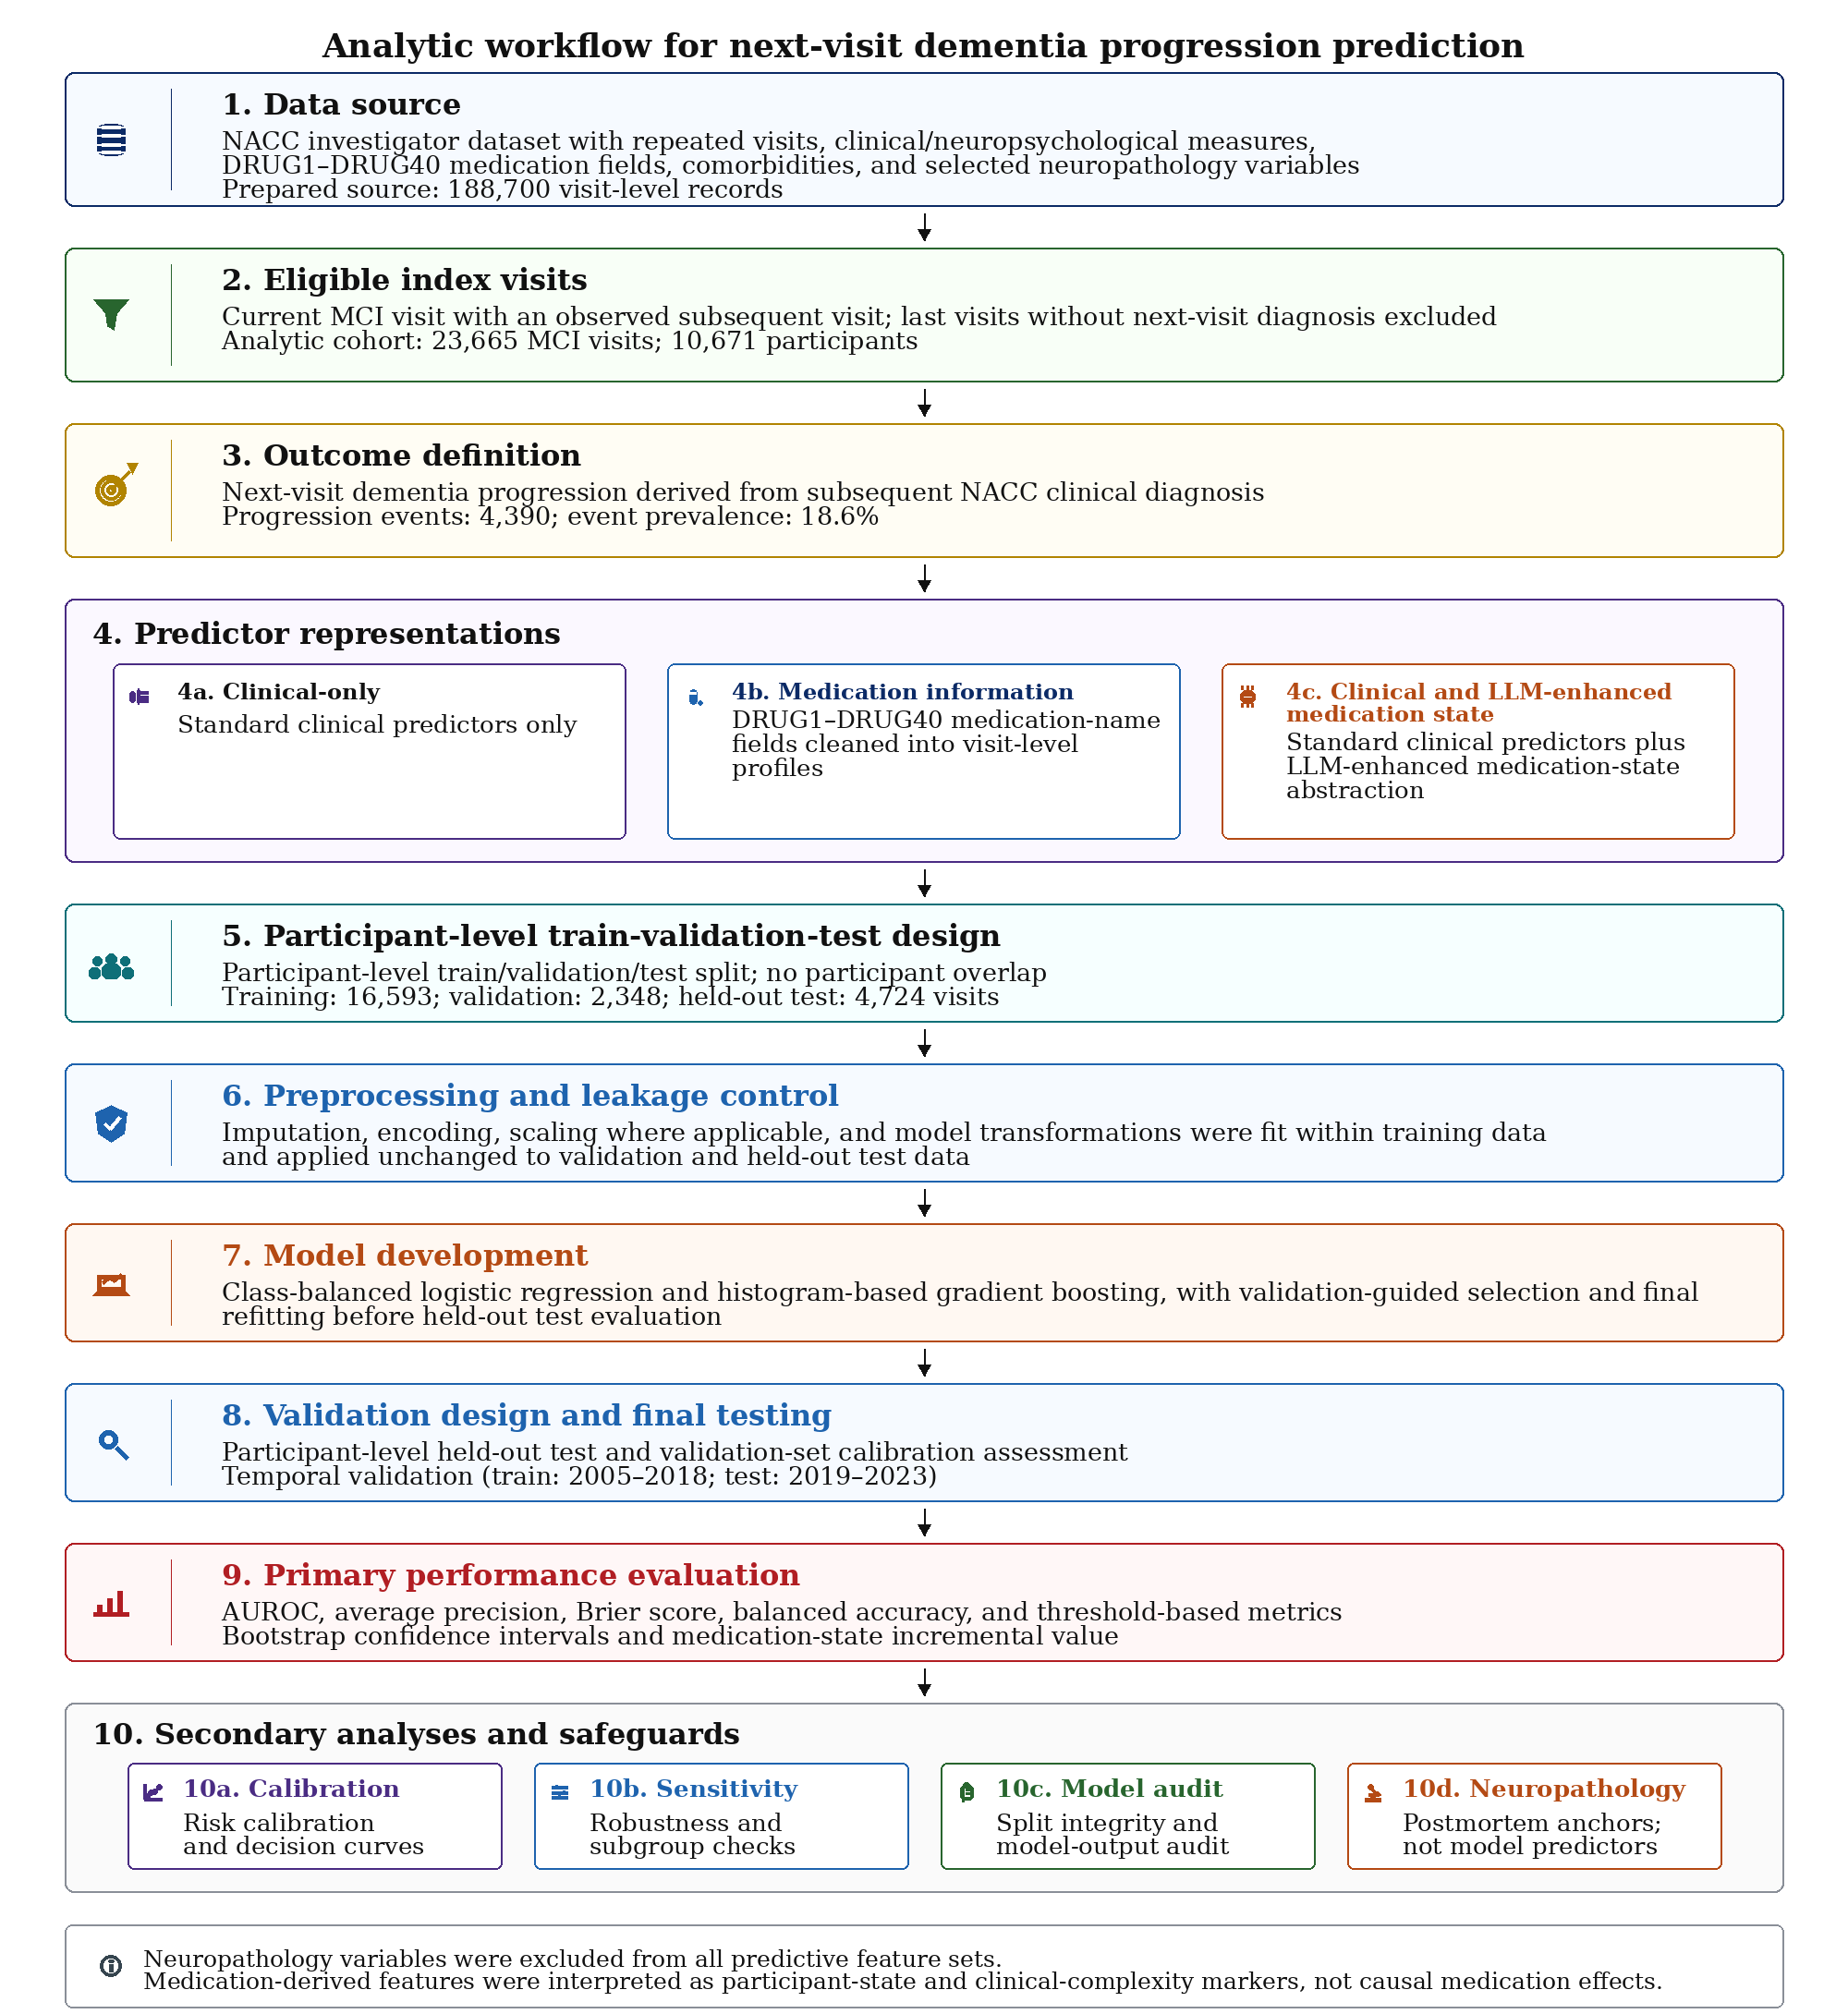

Saved PNG: ../op/0_pipeline_arch_flow_diagram/fig_pipeline_arch_flow_v0.png


In [6]:
# =============================================================================
# Run this cell to create the figure
# =============================================================================

img, paths = make_workflow_figure()